# 14 - ROC Curve and AUC

> 📘 **Instructor Curriculum**

**What it is:** a curve that shows how a classifier behaves at **every** cut-off,
not just the default one.

**Why we need it:** `predict()` hides a decision. It answers "class 1" only when
the probability is `>= 0.50`. Nobody chose that `0.50` - it is a default. Move it
and the model's mistakes change completely. Accuracy at one cut-off cannot show that.

**What you get at the end:**

| Question | Answer |
| --- | --- |
| How does the model behave at every cut-off? | the ROC curve |
| One number to compare two models | AUC |
| Which cut-off should I actually use? | the point on the curve you pick |

## Step 1 - Imports and data

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
import pandas as pd
from sklearn.datasets import make_classification

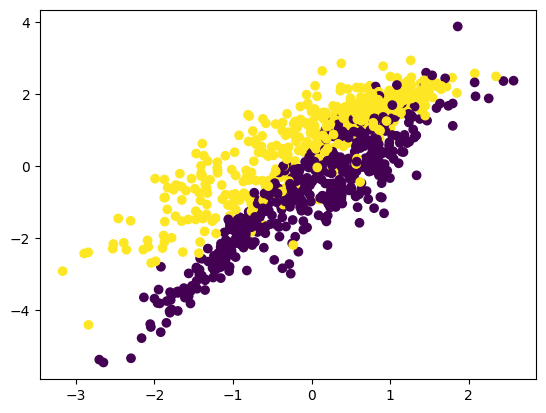

In [2]:
x,y = make_classification(n_classes=2,n_features=5,n_samples=1000,random_state=1)
plt.scatter(x[:,0],x[:,1],c=y)

`n_classes=2` is a yes/no problem. The scatter shows only 2 of the 5 features,
so the classes look mixed - that is fine, and it keeps the problem hard enough
to be interesting.

## Step 2 - Split, then train

In [3]:
X_train , X_test,Y_train, Y_test = train_test_split(x,y, test_size=0.2, random_state=1)

In [4]:
c1 = LogisticRegression()
c1.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Step 3 - The model returns a probability, not a label

This is the idea the whole notebook rests on. `predict_proba` gives the real
output; `predict` is just that probability compared against `0.5`.

In [5]:
proba = c1.predict_proba(X_test)      # column 0 = P(class 0), column 1 = P(class 1)
p1 = proba[:, 1]

print("first 5 probabilities of class 1:", p1[:5].round(3))
print("predict() is just p1 >= 0.5    :", (c1.predict(X_test) == (p1 >= 0.5)).all())

first 5 probabilities of class 1: [0.55  0.608 0.991 0.922 0.814]
predict() is just p1 >= 0.5    : True


`0.5` is a **default, not a law**. Nothing in your data chose it.

## Step 4 - What the curve plots

Two rates, both read off the confusion matrix:

```text
TPR (recall) = TP / (TP + FN)   of all real 1s, how many did we catch?
FPR          = FP / (FP + TN)   of all real 0s, how many did we wrongly flag?
```

Lower the threshold → you catch more real 1s (**TPR up**) but raise more false
alarms (**FPR up**). You cannot improve one without paying in the other.
The ROC curve draws that trade for every threshold at once.

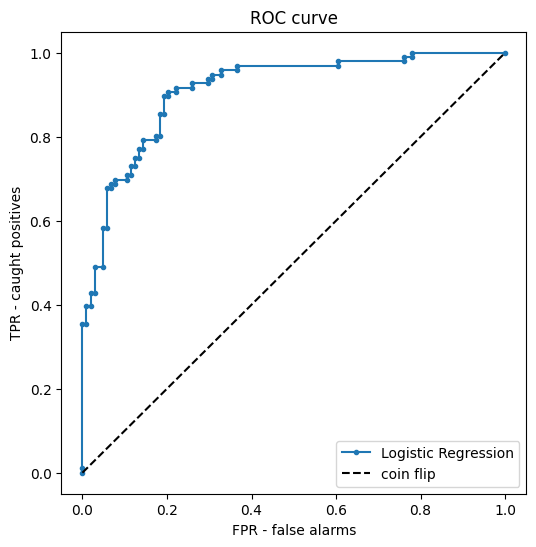

In [6]:
fpr, tpr, thresholds = metrics.roc_curve(Y_test, p1)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker=".", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="coin flip")
plt.xlabel("FPR - false alarms")
plt.ylabel("TPR - caught positives")
plt.title("ROC curve")
plt.legend()
plt.show()

How to read it:

- **Top-left corner** = perfect (catch everything, no false alarms).
- **Dashed diagonal** = a coin flip. Below it means the model is worse than guessing.
- **High threshold** sits bottom-left: cautious, few alarms, misses a lot.
- **Low threshold** sits top-right: catches nearly everything, but shouts constantly.

Each dot is one threshold. Picking a threshold means picking a point on this curve.

## Step 5 - AUC: one number for the whole curve

**AUC** is the area under that curve. Read it as: *pick one random positive row
and one random negative row - how often does the model score the positive one
higher?* `1.0` is perfect, `0.5` is a coin flip.

It never uses a threshold, which is why it is the fair way to compare two models.

In [7]:
print("AUC     :", round(metrics.roc_auc_score(Y_test, p1), 3))
print("accuracy:", round(c1.score(X_test, Y_test), 3))

AUC     : 0.912
accuracy: 0.815


**AUC = 0.912** while accuracy at the default cut-off is only **0.815**.
The ranking is good; the cut-off is the weak part.

For example, moving the threshold from `0.50` down to about `0.35` raises recall
from `0.77` to `0.91` - the model was always able to do that, the default was
just hiding it.

## Step 6 - The error in your last cell

`metrics.plot_roc_curve` was **removed in scikit-learn 1.2**. You are on 1.9, so
the call raises `AttributeError`. The cell is kept below so the error is on record.

In [8]:
metrics.plot_roc_curve(c1,X_test,Y_test)

AttributeError: module 'sklearn.metrics' has no attribute 'plot_roc_curve'

### The fix

`RocCurveDisplay` replaced it. Same picture, one line:

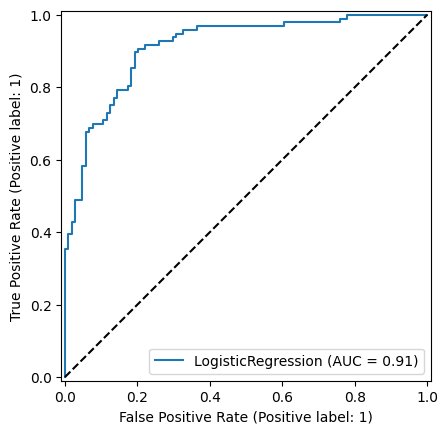

In [9]:
metrics.RocCurveDisplay.from_estimator(c1, X_test, Y_test)
plt.plot([0, 1], [0, 1], "k--")
plt.show()

---

## Common mistakes

1. **Treating `0.5` as part of the model.** It is a default you are allowed to change.
2. **Reporting accuracy on imbalanced data.** A model that always says "no" can score 95% and catch zero positives - AUC exposes that, accuracy does not.
3. **Using `plot_roc_curve`.** Removed in sklearn 1.2; use `RocCurveDisplay`.

## Key takeaway

> **If you remember only one thing...**
> A classifier does not output a label, it outputs a **score**. ROC shows what
> happens at every possible cut-off of that score, and AUC says how good the
> ranking is before you pick one.

Related: the four boxes these rates come from → [15_Model_Evaluation.ipynb](15_Model_Evaluation.ipynb).